# Tariikhna — End-to-End Test Pipeline
**Story → Structured Panels (Llama-3 8b via Ollama) → Comic Images (fal.ai) → Visual Result**

Place this notebook inside your `New_Progress/` folder alongside your JSON files.

## Step 1 — Install dependencies
Run this once. Restart the kernel after if needed.

In [6]:
!pip install requests Pillow fal-client --quiet groq


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 2 — Configuration
Set your fal.ai API key here. Get it from https://fal.ai/dashboard/keys

In [2]:
import os

# ── PASTE YOUR FAL.AI KEY HERE ──────────────────────────────
FAL_API_KEY = "0de17aeb-1e1b-42a7-9c78-c9f0d2ee6b51:c30735f7b3792f63391ae672b69dc3d2"
# ────────────────────────────────────────────────────────────

os.environ["FAL_KEY"] = FAL_API_KEY

# Ollama runs locally — no key needed
OLLAMA_BASE_URL = "http://localhost:11434"
OLLAMA_MODEL    = "llama3:8b"

# Image model on fal.ai (fast + good quality, ~$0.003/image)
IMAGE_MODEL = "fal-ai/flux/schnell"

print("✓ Config set")
print(f"  LLM  : {OLLAMA_MODEL} via Ollama (local)")
print(f"  Image: {IMAGE_MODEL} via fal.ai")

✓ Config set
  LLM  : llama3:8b via Ollama (local)
  Image: fal-ai/flux/schnell via fal.ai


## Step 3 — Check Ollama is running
If this fails, open a terminal and run: `ollama serve`  
If you haven't pulled the model yet: `ollama pull llama3:8b`

In [3]:
import requests

try:
    r = requests.get(f"{OLLAMA_BASE_URL}/api/tags", timeout=5)
    models = [m["name"] for m in r.json().get("models", [])]
    print("✓ Ollama is running")
    print(f"  Available models: {models}")
    if not any("llama3" in m for m in models):
        print("\n⚠ llama3:8b not found. Run in terminal: ollama pull llama3:8b")
    else:
        print("✓ llama3:8b is ready")
except Exception as e:
    print(f"✗ Ollama not reachable: {e}")
    print("  → Open a terminal and run: ollama serve")

✓ Ollama is running
  Available models: ['llama3:8b']
✓ llama3:8b is ready


## Step 4 — Load a story passage from your data

In [4]:
import json

# Load your curated passages
with open("curated_passages_287.json", "r", encoding="utf-8") as f:
    passages = json.load(f)

print(f"Loaded {len(passages)} passages")
print()

# ── CHOOSE A PASSAGE ──────────────────────────────────────────
# Change this index to test different stories (0 to 286)
PASSAGE_INDEX = 0
# ─────────────────────────────────────────────────────────────

passage = passages[PASSAGE_INDEX]
print(f"Testing passage: {passage['id']}")
print(f"Chapter       : {passage['chapter_title']}")
print(f"Scene types   : {passage['scene_types']}")
print(f"Word count    : {passage['word_count']}")
print()
print("PASSAGE TEXT:")
print("-" * 60)
print(passage["passage"])
print("-" * 60)

Loaded 287 passages

Testing passage: passage_0030
Chapter       : A Glance Back in History
Scene types   : ['miracle', 'dialogue', 'emotional']
Word count    : 107

PASSAGE TEXT:
------------------------------------------------------------
She then heard the angel asking her who she was. She answered: “I am Hagar, the mother of Abraham’s son.” He asked her: “To whom has he entrusted you in this barren place?” She replied: “He entrusted us to the care of God.” The angel rejoined: “He has then trusted you to the All-Merciful, the Compassionate.” At this point, while the boy was still rubbing his leg against the earth, water gushed forth between his feet. Hagar shouted: “God is Supreme.” She rushed back to her son and began to form a barrier around the new-found spring so that the water would not run into the valley.
------------------------------------------------------------


## Step 5 — Generate structured comic panel via Llama-3 8b

In [7]:
from groq import Groq

# ── System prompt: your schema + Islamic rules ──────────────────
SYSTEM_PROMPT = """You are Tariikhna, an AI that converts Islamic historical narratives into structured comic panel descriptions for children aged 6-12.

Given a passage, output ONE JSON object describing ONE comic panel.

CRITICAL ISLAMIC DEPICTION RULES:
- Prophets (Muhammad, Ibrahim, Musa, Isa, Ismail, ALL prophets): NEVER show face. depiction_rule must be NO_FACE, FROM_BEHIND, or SILHOUETTE.
- Angels: represent as light or voice only, never humanoid.
- Sahaba (Abu Bakr, Umar, Ali, etc.): faces allowed, depiction_rule = FULL.
- Women: modest clothing (hijab/khimar covering hair). Face and hands may be visible.
- No graphic violence. Battles shown through dust, distant silhouettes, or aftermath only.
- No modern objects. All items must be historically accurate to 7th century Arabia.
- Content must be appropriate and non-frightening for children aged 6-12.

Output ONLY valid JSON with this exact structure:
{
  "scene_title": "short descriptive title",
  "era": "one of: pre_islamic_prophets | ancient_prophets | pre_prophetic | early_makkah | late_makkah | madinah_early | madinah_late",
  "region": "one of: makkah | madinah | arabian_desert | egypt_ancient | levant_ancient | sinai | abyssinia | other",
  "source_reference": "source from the passage",
  "characters": [
    {
      "id": "lowercase_id",
      "name": "Full Name",
      "role": "one of: prophet | sahabi | family_of_prophet | antagonist | supporting | crowd",
      "depiction_rule": "one of: NO_FACE | FROM_BEHIND | SILHOUETTE | FULL",
      "appearance": "detailed physical description: age, skin tone, build, clothing with colors, headwear, footwear"
    }
  ],
  "moral_lesson": "the Islamic value this scene teaches",
  "narrative_text": "simple engaging story text for children aged 6-12, 2-3 sentences",
  "compliance": {
    "prophet_check": "NO_PROPHET_IN_SCENE | PROPHET_FROM_BEHIND | PROPHET_SILHOUETTE | PROPHET_NOT_VISIBLE",
    "modesty_check": "COMPLIANT",
    "child_safe": "APPROPRIATE",
    "notes": "brief compliance explanation"
  },
  "image_prompt": "80-120 word visual description for image generation. Start with art style. Include character appearances, setting, lighting, composition. End with No modern objects."
}

Respond with ONLY valid JSON. No markdown fences. No explanation."""

# ── Few-shot example ────────────────────────────────────────────
FEW_SHOT = """EXAMPLE INPUT: "Abu Bakr wept with joy when the Prophet told him he would be his companion on the journey."
Source: Ibn Hisham, Al-Sira, Vol. 2

EXAMPLE OUTPUT:
{"scene_title":"Abu Bakr Learns He Will Accompany the Prophet","era":"late_makkah","region":"makkah","source_reference":"Ibn Hisham, Al-Sira Al-Nabawiyya, Vol. 2","characters":[{"id":"prophet_muhammad","name":"Prophet Muhammad (PBUH)","role":"prophet","depiction_rule":"FROM_BEHIND","appearance":"Early 50s, medium build, dignified upright posture. White thobe with green cloak over shoulders, white turban. Simple leather sandals. Always shown from behind, face never visible."},{"id":"abu_bakr","name":"Abu Bakr al-Siddiq","role":"sahabi","depiction_rule":"FULL","appearance":"Late 40s, light olive skin, slender build. Thin grey-streaked beard with henna tint. Off-white thobe, brown woolen cloak, white cloth head wrap. Worn leather sandals. Kind gentle eyes."}],"moral_lesson":"True friendship means being ready to sacrifice everything for the sake of Allah.","narrative_text":"When the Prophet told Abu Bakr he would be his companion on the journey, Abu Bakr cried tears of joy. He had been preparing for this day — he had fed two strong camels for months!","compliance":{"prophet_check":"PROPHET_FROM_BEHIND","modesty_check":"COMPLIANT","child_safe":"APPROPRIATE","notes":"Prophet shown from behind, backlit by doorway. Abu Bakr with full face showing tears of joy. Warm emotional scene appropriate for children."},"image_prompt":"Children's watercolor illustration. Interior of a modest 7th century Makkah mud-brick home. A man in white thobe and green cloak, white turban, seen entirely from behind, standing at an open doorway with warm golden afternoon sunlight streaming behind him. A slender older Arab man with light olive skin, thin grey-streaked beard, off-white thobe and brown cloak, sitting on a woven mat with tears of joy. Clay water jug in corner, small oil lamp. Medium shot, eye level. Warm golden palette. No modern objects."}
"""

user_message = f"""{FEW_SHOT}
Now convert this passage:

INPUT: "{passage['passage']}"
Source: {passage['source']}

OUTPUT:"""

# ── Call Groq ───────────────────────────────────────────────────
GROQ_API_KEY = "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"
client = Groq(api_key=GROQ_API_KEY)

print("⏳ Calling Llama-3.1 8b via Groq (cloud)...")

response = client.chat.completions.create(
    model="llama-3.1-8b-instant",
    messages=[
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": user_message}
    ],
    temperature=0.7,
    max_tokens=2000,
    response_format={"type": "json_object"}
)

raw_response = response.choices[0].message.content
print(f"✓ Response received in {response.usage.completion_time:.2f} seconds")
print()
print("RAW LLM OUTPUT:")
print("-" * 60)
print(raw_response)
print("-" * 60)

⏳ Calling Llama-3.1 8b via Groq (cloud)...
✓ Response received in 0.90 seconds

RAW LLM OUTPUT:
------------------------------------------------------------
{
  "scene_title":"Hagar Finds Water in the Desert",
   "era":"ancient_prophets",
   "region":"arabian_desert",
   "source_reference":"Adil Salahi, Muhammad: Man and Prophet, Ch. 1: A Glance Back in History",
   "characters":[
      {
         "id":"hagar",
         "name":"Hagar",
         "role":"family_of_prophet",
         "depiction_rule":"FULL",
         "appearance":"Middle-aged woman, dark skin, worn out from traveling. Simple tattered dress, headscarf covering hair. Sandaled feet, carrying a waterskin on her shoulder."
      },
      {
         "id":"angel",
         "name":"Angel (Voice)",
         "role":"angel",
         "depiction_rule":"LIGHT",
         "appearance":"Glowing light above, no humanoid form. Radiant aura surrounding him."
      },
      {
         "id":"ibrahim_ismael",
         "name":"Ibrahim and Ismai

## Step 6 — Parse and validate the LLM output

In [8]:
import re

def parse_llm_output(raw_text):
    """Extract and parse JSON from LLM response, handling markdown fences."""
    text = raw_text.strip()

    # Remove markdown code fences if present
    if "```" in text:
        match = re.search(r"```(?:json)?\s*([\s\S]+?)```", text)
        if match:
            text = match.group(1).strip()

    # Find the JSON object
    start = text.find("{")
    end   = text.rfind("}") + 1
    if start == -1 or end == 0:
        raise ValueError("No JSON object found in response")

    text = text[start:end]
    return json.loads(text)

def validate_panel(panel):
    """Check for critical schema and compliance violations."""
    issues   = []
    warnings = []

    # Required fields
    for field in ["scene_title", "era", "region", "characters",
                  "moral_lesson", "narrative_text", "compliance", "image_prompt"]:
        if field not in panel:
            issues.append(f"Missing required field: {field}")

    # Character checks
    for c in panel.get("characters", []):
        if c.get("role") == "prophet" and c.get("depiction_rule") == "FULL":
            issues.append(f"CRITICAL: Prophet '{c.get('name')}' has FULL depiction — face must be hidden")
        if not c.get("appearance") or len(c.get("appearance", "")) < 20:
            warnings.append(f"Character '{c.get('id')}' has a very short appearance description")

    # Image prompt length
    prompt_words = len(panel.get("image_prompt", "").split())
    if prompt_words < 40:
        warnings.append(f"Image prompt is short ({prompt_words} words — aim for 80-120)")

    return issues, warnings

# ── Parse ──────────────────────────────────────────────────────
try:
    panel = parse_llm_output(raw_response)
    print("✓ JSON parsed successfully")
except Exception as e:
    print(f"✗ JSON parse failed: {e}")
    print("  Try running the LLM cell again — sometimes it adds extra text")
    raise

# ── Validate ───────────────────────────────────────────────────
issues, warnings = validate_panel(panel)

if issues:
    print()
    for issue in issues:
        print(f"✗ ISSUE  : {issue}")
if warnings:
    for w in warnings:
        print(f"⚠ WARNING: {w}")
if not issues and not warnings:
    print("✓ Validation passed — no issues")

# ── Pretty print the panel ─────────────────────────────────────
print()
print("PARSED PANEL:")
print("-" * 60)
print(f"Scene title  : {panel.get('scene_title')}")
print(f"Era          : {panel.get('era')}")
print(f"Region       : {panel.get('region')}")
print(f"Moral lesson : {panel.get('moral_lesson')}")
print()
print(f"Narrative text:")
print(f"  {panel.get('narrative_text')}")
print()
print("Characters:")
for c in panel.get("characters", []):
    print(f"  [{c.get('depiction_rule')}] {c.get('name')} ({c.get('role')})")
    print(f"    {c.get('appearance', '')[:120]}...")
print()
print("Compliance:")
comp = panel.get("compliance", {})
print(f"  Prophet check : {comp.get('prophet_check')}")
print(f"  Modesty check : {comp.get('modesty_check')}")
print(f"  Child safe    : {comp.get('child_safe')}")
print(f"  Notes         : {comp.get('notes')}")
print()
print(f"Image prompt ({len(panel.get('image_prompt','').split())} words):")
print(f"  {panel.get('image_prompt')}")

✓ JSON parsed successfully
✓ Validation passed — no issues

PARSED PANEL:
------------------------------------------------------------
Scene title  : Hagar Finds Water in the Desert
Era          : ancient_prophets
Region       : arabian_desert
Moral lesson : Trust in Allah brings relief and solutions to problems.

Narrative text:
  Hagar told the angel her name and that she was the mother of Ibrahim's son. The angel asked her who had sent her to the desert. Hagar replied that Ibrahim had entrusted them to Allah's care. The angel confirmed that Allah, the All-Merciful, the Compassionate, had indeed taken care of them. Water suddenly gushed out from the ground, and Hagar thanked Allah saying: ‘God is Supreme’.

Characters:
  [FULL] Hagar (family_of_prophet)
    Middle-aged woman, dark skin, worn out from traveling. Simple tattered dress, headscarf covering hair. Sandaled feet, ca...
  [LIGHT] Angel (Voice) (angel)
    Glowing light above, no humanoid form. Radiant aura surrounding him...

## Step 7 — Generate panel image via fal.ai FLUX

In [9]:
import fal_client

image_prompt = panel.get("image_prompt", "")

# Safety check — never generate if compliance failed
if issues:
    print("✗ Skipping image generation — compliance issues must be fixed first")
    print("  Fix the issues listed above, then rerun from Step 5")
else:
    print("⏳ Generating image via fal.ai FLUX...")
    print(f"  Prompt: {image_prompt[:100]}...")
    print()

    try:
        result = fal_client.run(
            IMAGE_MODEL,
            arguments={
                "prompt": image_prompt,
                "image_size": "landscape_4_3",
                "num_inference_steps": 4,
                "num_images": 1,
                "enable_safety_checker": True
            }
        )

        image_url = result["images"][0]["url"]
        print(f"✓ Image generated")
        print(f"  URL: {image_url}")

    except Exception as e:
        print(f"✗ Image generation failed: {e}")
        raise

⏳ Generating image via fal.ai FLUX...
  Prompt: Watercolor illustration with warm desert colors. Hagar, a middle-aged woman with dark skin, stands i...

✓ Image generated
  URL: https://v3b.fal.media/files/b/0a989df2/8PQYk4qgEIViqVwqm3yWx.jpg


## Step 8 — Download and display the comic panel

⏳ Rendering comic panel...
✓ Saved to test_output/Hagar_Finds_Water_in_the_Desert.png



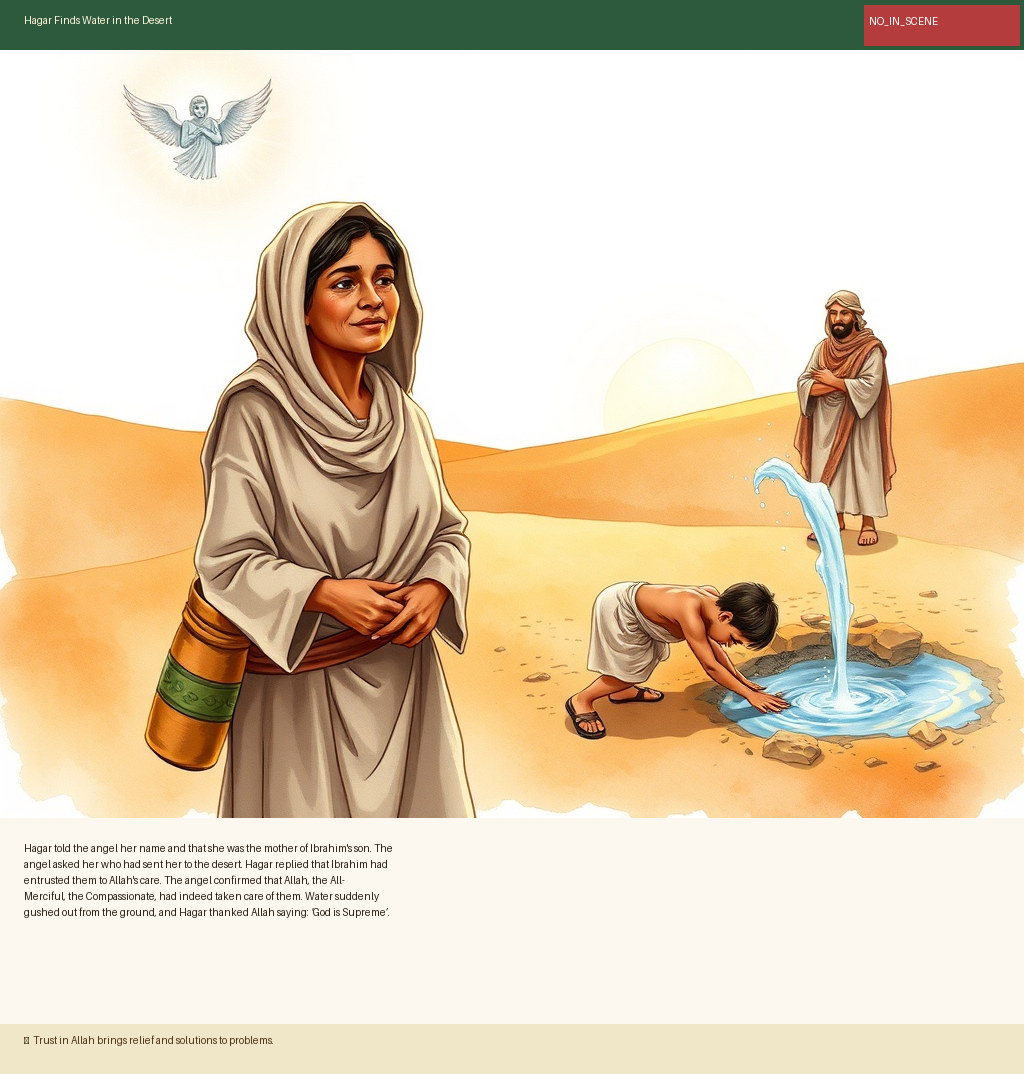

In [10]:
import requests
from PIL import Image, ImageDraw, ImageFont
from io import BytesIO
import textwrap
import os
from IPython.display import display

def render_comic_panel(panel_data, image_url):
    """Download the image and render a full comic panel with title and text."""

    # Download image
    r = requests.get(image_url, timeout=30)
    comic_img = Image.open(BytesIO(r.content)).convert("RGB")

    img_w, img_h = comic_img.size

    # Panel dimensions
    padding      = 24
    title_h      = 50
    text_h       = 110
    lesson_h     = 50
    total_h      = title_h + img_h + text_h + lesson_h + padding * 4

    # Canvas
    canvas = Image.new("RGB", (img_w, total_h), color=(252, 248, 240))
    draw   = ImageDraw.Draw(canvas)

    # Title bar
    draw.rectangle([0, 0, img_w, title_h], fill=(45, 90, 60))

    # Try to load a font, fall back to default
    try:
        font_title = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 20)
        font_body  = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 15)
        font_small = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Oblique.ttf", 13)
    except:
        font_title = ImageFont.load_default()
        font_body  = font_title
        font_small = font_title

    # Draw scene title
    title_text = panel_data.get("scene_title", "")
    draw.text((padding, 14), title_text, fill=(255, 245, 220), font=font_title)

    # Paste the comic image
    canvas.paste(comic_img, (0, title_h))

    # Narrative text area
    text_y = title_h + img_h + padding
    narrative = panel_data.get("narrative_text", "")
    wrapped   = textwrap.fill(narrative, width=80)
    draw.multiline_text((padding, text_y), wrapped, fill=(40, 30, 20), font=font_body, spacing=6)

    # Moral lesson bar
    lesson_y = total_h - lesson_h
    draw.rectangle([0, lesson_y, img_w, total_h], fill=(240, 230, 200))
    moral = "✦  " + panel_data.get("moral_lesson", "")
    moral_wrapped = textwrap.fill(moral, width=90)
    draw.multiline_text((padding, lesson_y + 10), moral_wrapped, fill=(80, 50, 20), font=font_small, spacing=4)

    # Compliance badge (top right corner)
    comp       = panel_data.get("compliance", {})
    badge_text = comp.get("prophet_check", "").replace("PROPHET_", "")
    badge_col  = (60, 120, 80) if "BEHIND" in badge_text or "NOT_VISIBLE" in badge_text or "SILHOUETTE" in badge_text or "NO_PROPHET" in badge_text else (180, 60, 60)
    draw.rectangle([img_w - 160, 5, img_w - 5, title_h - 5], fill=badge_col)
    draw.text((img_w - 155, 15), badge_text, fill=(255, 255, 255), font=font_small)

    return canvas

# ── Render and display ─────────────────────────────────────────
print("⏳ Rendering comic panel...")
comic = render_comic_panel(panel, image_url)

# Save
os.makedirs("test_output", exist_ok=True)
safe_name = panel.get("scene_title", "panel").replace(" ", "_").replace("/", "-")[:50]
save_path = f"test_output/{safe_name}.png"
comic.save(save_path)

print(f"✓ Saved to {save_path}")
print()

# Display inline
display(comic)

## Step 9 — Save full panel JSON output

In [11]:
full_output = {
    "passage_id"    : passage["id"],
    "chapter_title" : passage["chapter_title"],
    "input_passage" : passage["passage"],
    "panel"         : panel,
    "generated_image_url": image_url
}

json_path = f"test_output/{safe_name}.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(full_output, f, indent=2, ensure_ascii=False)

print(f"✓ Full panel JSON saved: {json_path}")
print()
print("── SUMMARY ────────────────────────────────────────")
print(f"  Input passage : {passage['id']} — {passage['chapter_title']}")
print(f"  Scene title   : {panel.get('scene_title')}")
print(f"  Era / Region  : {panel.get('era')} / {panel.get('region')}")
print(f"  Characters    : {[c['name'] for c in panel.get('characters', [])]}")
print(f"  Prophet rule  : {panel.get('compliance', {}).get('prophet_check')}")
print(f"  Image saved   : {save_path}")
print(f"  JSON saved    : {json_path}")
print("────────────────────────────────────────────────────")

✓ Full panel JSON saved: test_output/Hagar_Finds_Water_in_the_Desert.json

── SUMMARY ────────────────────────────────────────
  Input passage : passage_0030 — A Glance Back in History
  Scene title   : Hagar Finds Water in the Desert
  Era / Region  : ancient_prophets / arabian_desert
  Characters    : ['Hagar', 'Angel (Voice)', 'Ibrahim and Ismail']
  Prophet rule  : NO_PROPHET_IN_SCENE
  Image saved   : test_output/Hagar_Finds_Water_in_the_Desert.png
  JSON saved    : test_output/Hagar_Finds_Water_in_the_Desert.json
────────────────────────────────────────────────────


## Step 10 — (Optional) Test multiple passages in a batch

In [12]:
import time
from IPython.display import display

# ── Choose which passages to batch test ───────────────────────
# Change these indices to any passages you want to test
BATCH_INDICES = [0, 4, 6]   # e.g. 3 different stories
# ─────────────────────────────────────────────────────────────

print(f"Running batch test on {len(BATCH_INDICES)} passages...")
print()

for idx in BATCH_INDICES:
    p = passages[idx]
    print(f"[{idx}] {p['id']} — {p['chapter_title']}")

    try:
        # LLM call
        user_msg = f"{FEW_SHOT}\nNow convert:\nINPUT: \"{p['passage']}\"\nSource: {p['source']}\nOUTPUT:"
        resp = requests.post(
            f"{OLLAMA_BASE_URL}/api/chat",
            json={
                "model": OLLAMA_MODEL,
                "messages": [
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user",   "content": user_msg}
                ],
                "stream": False,
                "options": {"temperature": 0.7, "num_predict": 2000}
            },
            timeout=120
        )
        pnl = parse_llm_output(resp.json()["message"]["content"])
        issues, _ = validate_panel(pnl)

        if issues:
            print(f"  ✗ Compliance issue: {issues[0]}")
            continue

        # Image generation
        img_result = fal_client.run(
            IMAGE_MODEL,
            arguments={
                "prompt": pnl["image_prompt"],
                "image_size": "landscape_4_3",
                "num_inference_steps": 4,
                "num_images": 1,
                "enable_safety_checker": True
            }
        )
        url = img_result["images"][0]["url"]

        # Render
        comic = render_comic_panel(pnl, url)
        safe  = pnl.get("scene_title", str(idx)).replace(" ", "_")[:40]
        comic.save(f"test_output/{safe}.png")
        display(comic)
        print(f"  ✓ Done: {pnl.get('scene_title')}")

    except Exception as e:
        print(f"  ✗ Error: {e}")

    time.sleep(2)   # small delay between calls
    print()

print("Batch complete. All panels saved to test_output/")

Running batch test on 3 passages...

[0] passage_0030 — A Glance Back in History
  ✗ Error: HTTPConnectionPool(host='localhost', port=11434): Read timed out. (read timeout=120)

[4] passage_0152 — A Glance Back in History
  ✗ Error: HTTPConnectionPool(host='localhost', port=11434): Read timed out. (read timeout=120)

[6] passage_0186 — A Glance Back in History
  ✗ Error: HTTPConnectionPool(host='localhost', port=11434): Read timed out. (read timeout=120)

Batch complete. All panels saved to test_output/
